<h1>Импорт библиотек

In [3]:
import numpy as np
import matplotlib.pyplot as plt

KeyboardInterrupt: 

<h1>Задача 1. Дан набор из $p$ матриц размерностью $(n, n)$ и $p$ векторов размерностью $(n, 1)$, найти сумму произведений матриц на векторы. Написать тесты для кода

In [11]:
def sum_prod(X, V):
    '''
    X - матрицы (n, n)
    V - векторы (n, 1)
    Гарантируется, что len(X) == len(V)
    '''

    n = len(X[0])  # размерность

    # результирующий вектор
    result = [0] * n

    for matrix, vector in zip(X, V):
        # проверка размеров
        if len(matrix) != n or any(len(row) != n for row in matrix):
            raise ValueError("Matrix must be n x n")

        if len(vector) != n:
            raise ValueError("Vector must be of size n")

        # умножение матрицы на вектор
        for i in range(n):
            for j in range(n):
                result[i] += matrix[i][j] * vector[j]

    return result

print(sum_prod([[[1, 0], [0, 1]]], [[5, 7]])) # 5, 7
print(sum_prod([[[1, 0],[0, 1]], [[2, 0],[0, 2]]],[[1, 1],[1, 1]])) # 3, 3

[5, 7]
[3, 3]


<h1>Задача 2. Дана матрица M, напишите функцию, которая бинаризует матрицу по некоторому threshold (то есть, все значения большие threshold становятся равными 1, иначе 0). Напишите тесты для кода

In [16]:
def binarize(M, threshold=0.5):
    if not M:
        return []

    result = []

    for row in M:
        new_row = []
        for value in row:
            new_row.append(1 if value > threshold else 0)
        result.append(new_row)

    return result

print(binarize([]))
binarize([[0.5, 0.6]]) # [0, 1]

[]


[[0, 1]]

<h1>Задача 3. Напишите функцию, которая возвращает уникальные элементы из каждой строки матрицы. Напишите такую же функцию, но для столбцов. Напишите тесты для кода

In [18]:
def unique_rows(mat):
    # Your code goes here
    result = []

    for row in mat:
        seen = set()
        unique = []
        for x in row:
            if x not in seen:
                seen.add(x)
                unique.append(x)
        result.append(unique)

    return result

def unique_columns(mat):
    # Your code goes here
    if not mat:
        return []

    n_cols = len(mat[0])
    result = []

    for j in range(n_cols):
        seen = set()
        unique = []
        for i in range(len(mat)):
            val = mat[i][j]
            if val not in seen:
                seen.add(val)
                unique.append(val)
        result.append(unique)

    return result

print(unique_rows([[1, 2, 2, 3],[3, 3, 1]])) # [1, 2, 3], [3, 1]
print(unique_columns([[1, 2, 2],[1, 3, 2],[4, 2, 5]])) # [1, 4], [2, 3],[2, 5] 

[[1, 2, 3], [3, 1]]
[[1, 4], [2, 3], [2, 5]]


<h1>Задача 4. Напишите функцию, которая заполняет матрицу с размерами $(m, n)$ случайными числами, распределенными по нормальному закону. Затем считает мат. ожидание и дисперсию для каждого из столбцов и строк, а также строит для каждой строки и столбца гистограмму значений (использовать функцию hist из модуля matplotlib.plot)

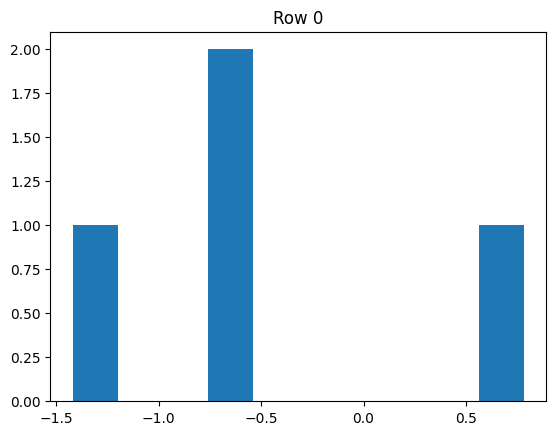

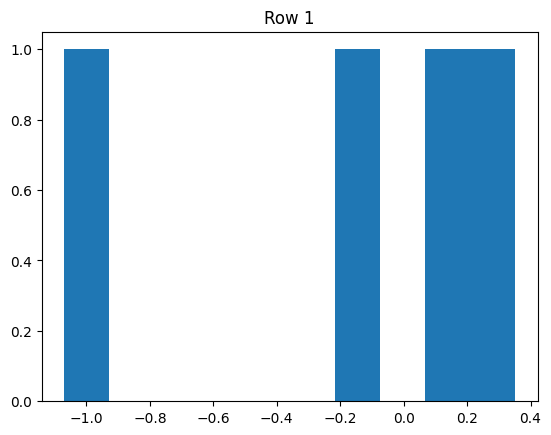

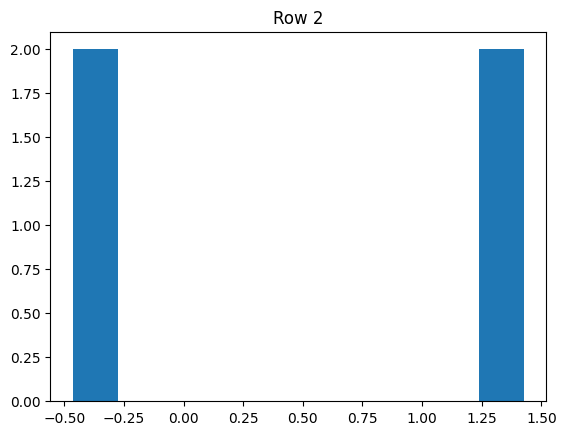

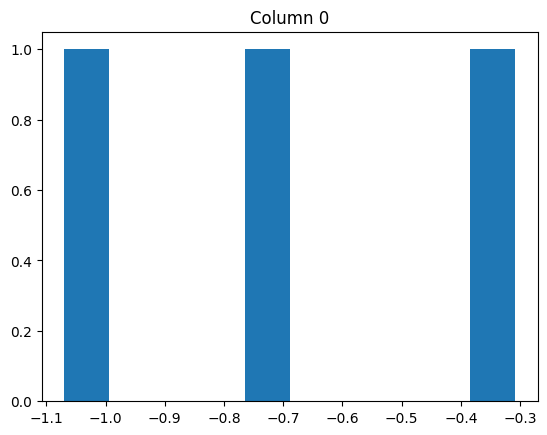

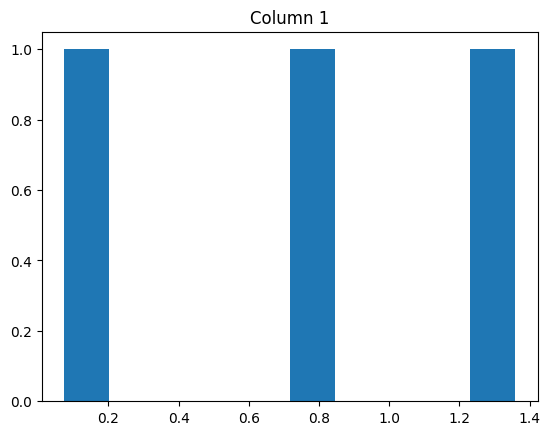

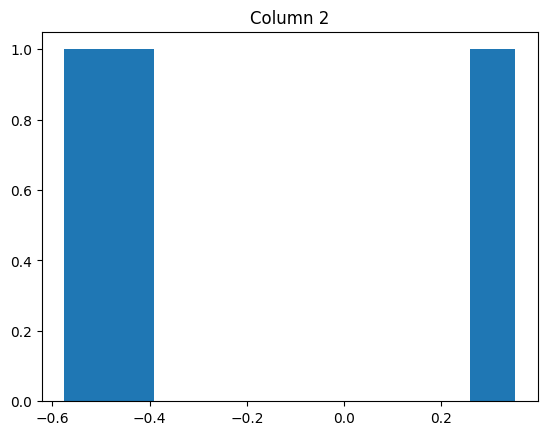

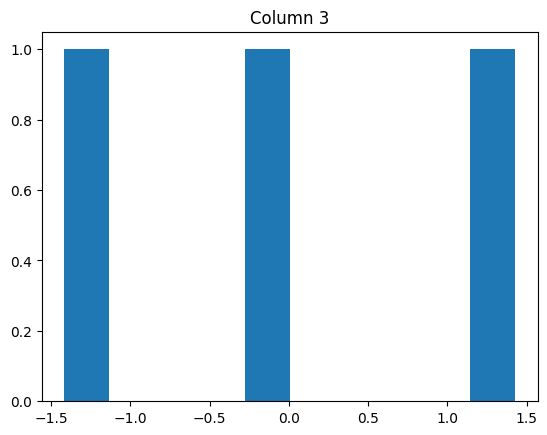

{'matrix': [[-0.7111546448294106,
   0.7827884576912493,
   -0.575323040742968,
   -1.4174783411445824],
  [-1.069780286966781,
   0.07414804952650762,
   0.3516805457650206,
   -0.20622462901615746],
  [-0.3082645552686767,
   1.358979120706909,
   -0.4636943721142782,
   1.4269213334346267]],
 'row_means': [-0.48029189225642793, -0.21254408017285253, 0.5034853816896452],
 'row_vars': [0.6340047350279453, 0.2838589138619131, 0.794744532698239],
 'col_means': [-0.6963998290216228,
  0.7386385426415553,
  -0.22911228903074188,
  -0.06559387890870443],
 'col_vars': [0.09675988723204405,
  0.2761064210778772,
  0.1707369850850179,
  1.3583234220622773]}

In [23]:
# Your code goes here
import random
import matplotlib.pyplot as plt


def generate_matrix(m, n, mu=0, sigma=1):
    return [[random.gauss(mu, sigma) for _ in range(n)] for _ in range(m)]


def mean(arr):
    return sum(arr) / len(arr)


def variance(arr):
    m = mean(arr)
    return sum((x - m) ** 2 for x in arr) / len(arr)


def analyze_matrix(m, n):
    M = generate_matrix(m, n)

    # строки
    row_means = [mean(row) for row in M]
    row_vars = [variance(row) for row in M]

    # столбцы
    cols = list(zip(*M))
    col_means = [mean(col) for col in cols]
    col_vars = [variance(col) for col in cols]

    #гистограммы строк
    for i, row in enumerate(M):
        plt.figure()
        plt.hist(row)
        plt.title(f"Row {i}")
        plt.show()

    # гистограммы столбцов 
    for j, col in enumerate(cols):
        plt.figure()
        plt.hist(col)
        plt.title(f"Column {j}")
        plt.show()

    return {
        "matrix": M,
        "row_means": row_means,
        "row_vars": row_vars,
        "col_means": col_means,
        "col_vars": col_vars
    }


<h1>Задача 5. Напишите функцию, которая заполняет матрицу $(m, n)$ в шахматном порядке заданными числами $a$ и $b$. Напишите тесты для кода

In [28]:
def chess(m, n, a, b):
    # Your code goes here
    matrix = []

    for i in range(m):
        row = []
        for j in range(n):
            if (i + j) % 2 == 0:
                row.append(a)
            else:
                row.append(b)
        matrix.append(row)

    return matrix
print(chess(3, 3, "A", "B"))
print(chess(1, 5, 7, 10))

[['A', 'B', 'A'], ['B', 'A', 'B'], ['A', 'B', 'A']]
[[7, 10, 7, 10, 7]]


<h1>Задача 6. Напишите функцию, которая отрисовывает прямоугольник с заданными размерами (a, b) на изображении размера (m, n), цвет фона задайте в схеме RGB, как и цвет прямоугольника. Цвета также должны быть параметрами функции. Напишите аналогичную функцию но для овала с полуосями a и b. Напишите тесты для кода.
Примечание: уравнение эллипса (границы овала) можно записать как:
<h1>$\frac{(x-x_0)^2}{a^2}+\frac{(y-y_0)^2}{b^2}=1$

In [31]:
def draw_rectangle(a, b, m, n, rectangle_color, background_color):
    img = np.zeros((m, n, 3), dtype=np.uint8)

    img[:, :] = background_color

    x0, y0 = n // 2, m // 2

    for i in range(m):
        for j in range(n):
            if abs(j - x0) <= a // 2 and abs(i - y0) <= b // 2:
                img[i, j] = rectangle_color

    return img

def draw_ellipse(a, b, m, n, ellipse_color, background_color):
    # Your code goes here
    img = np.zeros((m, n, 3), dtype=np.uint8)
    img[:, :] = background_color

    x0, y0 = n // 2, m // 2

    for i in range(m):
        for j in range(n):
            if ((j - x0) ** 2) / (a ** 2) + ((i - y0) ** 2) / (b ** 2) <= 1:
                img[i, j] = ellipse_color

    return img

img = draw_rectangle(4, 4, 10, 10, (255, 0, 0), (0, 0, 0))
print(img[5, 5]) # центр должен быть красный ([255, 0, 0])

img = draw_ellipse(3, 2, 10, 10, (0, 255, 0), (0, 0, 0))
print(img[5, 5]) # центр всегда внутри элипса

[255   0   0]
[  0 255   0]


<h1>Задача 7. Дан некий временной ряд. Для данного ряда нужно найти его: математическое ожидание, дисперсию, СКО, найти все локальные максимумы и минимумы (локальный максимум - это точка, которая больше своих соседних точек, а локальный минимум - это точка, которая меньше своих соседей), а также вычислить для данного ряда другой ряд, получаемый методом скользящего среднего с размером окна $p$.
<h1>Примечание: метод скользящего среднего подразумевает нахождение среднего из подмножетсва ряда размером $p$

In [32]:
# Your code goes here
import numpy as np

def analysisTimeSeries(series, p):
    arr = np.array(series, dtype=float)

    # 1. Математическое ожидание
    mean = np.mean(arr)

    # 2. Дисперсия
    variance = np.var(arr)

    # 3. Среднеквадратичное отклонение
    std = np.std(arr)

    # 4. Локальные экстремумы
    local_max = []
    local_min = []

    for i in range(1, len(arr) - 1):
        if arr[i] > arr[i - 1] and arr[i] > arr[i + 1]:
            local_max.append((i, arr[i]))
        if arr[i] < arr[i - 1] and arr[i] < arr[i + 1]:
            local_min.append((i, arr[i]))

    # 5. Скользящее среднее
    moving_avg = []
    for i in range(len(arr) - p + 1):
        window = arr[i:i + p]
        moving_avg.append(np.mean(window))

    return {
        "mean": mean,
        "variance": variance,
        "std": std,
        "local_max": local_max,
        "local_min": local_min,
        "moving_average": moving_avg
    }

<h1> Задача 8. Дан некоторый вектор с целочисленными метками классов, напишите функцию, которая выполняет one-hot-encoding для данного вектора
<h1> One-hot-encoding - представление, в котором на месте метки некоторого класса стоит 1, в остальных позициях стоит 0. Например для вектора [0, 2, 3, 0] one-hot-encoding выглядит как: [[1, 0, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1], [1, 0, 0, 0]]

In [34]:
# Your code goes here
def one_hot_encoding(labels):
    # список целочисленных меток классов
    labels = np.array(labels)

    # число классов = max метка + 1
    num_classes = labels.max() + 1

    # создаем нулевую матрицу
    one_hot = np.zeros((len(labels), num_classes), dtype=int)

    # ставим 1 в нужные позиции
    one_hot[np.arange(len(labels)), labels] = 1

    return one_hot

one_hot_encoding([0, 2, 3, 0])

array([[1, 0, 0, 0],
       [0, 0, 1, 0],
       [0, 0, 0, 1],
       [1, 0, 0, 0]])